In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed


sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *
from utils import *

system = platform.system()

if system == 'Linux':
    home = '/home/gerard/data/confocal/'
elif system == 'Darwin':
    home = '/Users/gerard/data/confocal/'
elif system == "Windows":
    home = 'C:/Users/cviko/data/confocal/'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
date = '2026_06_15'
user = 'Carmina'


info = describe_acquisition( home + date + '_' + user + '/Project.lif')


══════════════════════════════════════════════════════════════
Scene 0: dec02_5x_brain3gamma_R8
══════════════════════════════════════════════════════════════
  Objective  : HC PL APO CS2    63x/1.40 OIL
  NA / n     : 1.4 / 1.518
  Voxel size : XY = 0.0226 µm/px  |  Z = 0.1307 µm/step
  Shape      : 108 × 512 × 512  (Z × Y × X)

  ────────────────────────────────────── Acquisition sequences
  Seq 1  laser(s): 488 nm + 638 nm  [simultaneous]
         pinhole  : 95.58 µm  (1.001 AU)
         det ch1  501–610 nm  Leica/ALEXA 488         em = 519 nm
         det ch2  643–788 nm  Leica/Cy5               em = 670 nm
  Seq 2  laser(s): 552 nm
         pinhole  : 95.58 µm  (1.001 AU)
         det ch2  552–802 nm  (unnamed)               em = 570 nm

  ────────────────────────────────────── Image channels (0-indexed)
  ch0  Leica/ALEXA 488         em=519 nm  σ_xy=3.45px (0.078µm) [✓]  σ_z=2.03px [✓]  → 3D
  ch1  Leica/Cy5               em=670 nm  σ_xy=4.45px (0.101µm) [✓]  σ_z=2.62px [✓]  → 3

In [3]:
loader2(date,user,False, False)

/home/gerard/data/confocal/2026_06_15_Carmina
Number of series: 12
series 0: shape = (1, 3, 108, 512, 512)
series 1: shape = (1, 3, 108, 512, 512)
series 2: shape = (1, 3, 58, 512, 512)
series 3: shape = (1, 3, 58, 512, 512)
series 4: shape = (1, 3, 58, 512, 512)
series 5: shape = (1, 3, 97, 512, 512)
series 6: shape = (1, 3, 59, 512, 512)
series 7: shape = (1, 3, 62, 512, 512)
series 8: shape = (1, 3, 101, 512, 512)
series 9: shape = (1, 3, 62, 512, 512)
series 10: shape = (1, 3, 66, 512, 512)
series 11: shape = (1, 3, 114, 512, 512)


### DECONVOLUTION :

In [4]:


path_data = date + '_' + user + '/Project.lif'
path_data_all = home + path_data #os.path.join(hom

print(path_data_all)
img = AICSImage(path_data_all)
# print(len(img.scenes))
# print(img.scenes[0])



/home/gerard/data/confocal/2026_06_15_Carmina/Project.lif


#### serial version 

In [23]:



#scenes = list(range(len(info.keys())))
scenes = [0]
flagged2d= []
flagged3d = []
## DESIRED NUMBER OF ITERATIONS:
iterations = [
      #      1,        
            2,
            # #3,
            #4,
            # 5,
            #6,
            # # 7, 
            # 10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            print(f'--------------> iteration {num_iter} for scene {scene} channel {channel}')
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter)
            flagged = analyze_deconvolution_results(result, stack)
            flagged3d.append(flagged)
            
            # result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter, forced2d = True)
            # flagged = analyze_deconvolution_results(result, stack)
            # flagged2d.append(flagged)
            

--------------> iteration 2 for scene 0 channel 0
0.209 <------------------ pinhole
Applying pinhole factor 0.768 to PSF σ values: σ_xy 3.45 px → 2.65 px, σ_z 2.03 px → 1.56 px
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (2.65 px) | σ_z=0.265 µm (1.56 px) → 2D-per-frame (σ_z=1.56 px < 2, Z undersampled)
2026_06_05_s0_ch0_deconv2d_iter_2.tif
0.131 of inspected frames flagged
--------------> iteration 2 for scene 0 channel 1
0.16189701492537312 <------------------ pinhole
Applying pinhole factor 0.755 to PSF σ values: σ_xy 4.45 px → 3.36 px, σ_z 2.62 px → 1.98 px
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (3.36 px) | σ_z=0.342 µm (1.98 px) → 2D-per-frame (σ_z=1.98 px < 2, Z undersampled)
2026_06_05_s0_ch1_deconv2d_iter_2.tif
0.000 of inspected frames flagged
--------------> iteration 2 for scene 0 channel 2
0.18930366492146594 <------------------ pinhole
Applying pinhole factor 0.763 to PSF σ values: σ_xy 3.81 px → 2.90 px, σ_z 2.24 px → 1.71 px
PSF (ch2): λ=573 nm | σ_xy=0.086 µm (2.90 px) | σ_z=0.293

#### parallelized version 

In [5]:
print(f'cpus: {os.cpu_count()}')


cpus: 24


In [6]:

n_jobs = os.cpu_count() - 2
print(f'n_jobs:{n_jobs}')
iterations = [
      #      1,        
            2,
            #3,
            4,
            #5,
            6,
            # 7, 
             10, 
            # 15,
            # 20,
            #20result[bg].std() / original[bg].std()
            ]

scenes = list(range(len(info.keys())))
# --- Phase 1: load all stacks sequentially (img is stateful) ---
stacks = {}
scene_channels = {}
for scene in scenes:
    img.set_scene(img.scenes[scene])
    channels = list(range(len(info[list(info.keys())[scene]]['image_channels'])))
    scene_channels[scene] = channels
    
    for channel in channels:
        stacks[(scene, channel)] = img.get_image_data("ZYX", T=0, C=channel)

# --- Phase 2: build flat job list ---
jobs = [
    (stacks[(scene, channel)], scene, channel, num_iter, forced2d)
    for scene in scenes
    for channel in scene_channels[scene]
    for num_iter in iterations
    for forced2d in [True]#[False, True]
]

def run_one(stack, scene, channel, num_iter, forced2d):
    result, sigma_xy_px = deconvolve(
        stack, path_data_all, channel=channel, scene=scene,
        num_iter=num_iter, forced2d=forced2d
    )
    flagged = analyze_deconvolution_results(result, stack)
    return (scene, channel, num_iter, forced2d, flagged)

# --- Run in parallel (threading shares imports & sys.path) ---
results = Parallel(n_jobs=n_jobs, backend='threading')(
    delayed(run_one)(*job) for job in jobs
)

# --- Reconstruct flagged lists ---
flagged3d = [r[-1] for r in results if not r[-2]]   # forced2d=False
flagged2d = [r[-1] for r in results if r[-2]]        # forced2d=True


n_jobs:22
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px → 3.69 px, σ_z 2.23 px → 2.17 px
PSF (ch2): λ=570 nm | σ_xy=0.083 µm (3.69 px) | σ_z=0.284 µm (2.17 px) → 2D-per-frame (σ_z=2.17 px, FORCED)
0.7754014925373133 <------------------ pinhole
Applying pinhole factor 0.934 to PSF σ values: σ_xy 4.45 px → 4.16 px, σ_z 2.62 px → 2.45 px
PSF (ch1): λ=670 nm | σ_xy=0.094 µm (4.16 px) | σ_z=0.320 µm (2.45 px) → 2D-per-frame (σ_z=2.45 px, FORCED)
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px → 3.69 px, σ_z 2.23 px → 2.17 px
PSF (ch2): λ=570 nm | σ_xy=0.083 µm (3.69 px) | σ_z=0.284 µm (2.17 px) → 2D-per-frame (σ_z=2.17 px, FORCED)
1.001 <------------------ pinhole
PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (2.03 px) → 2D-per-frame (σ_z=2.03 px, FORCED)
0.911436842105263 <------------------ pinhole
Applying pinhole factor 0.974 to PSF σ values: σ_xy 3.79 px 


### TRESHOLDING



| Method   |ch0: BRP (puncta)|ch1: HSP70 (diffuse) |ch2: Mitochondria| 
| --       | --              | --                  | --              |
| Otsu     | unstable        | weak performance    | good            |
| Triangle |  **very good**  | mediocre            | good            |
| Yen      | too strict      |often underestimates | ok              |
| Li       | good            |**best of the four** | good            |






[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
/home/gerard/data/confocal/2026_06_15_Carmina/Project.lif
Processing series 0---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_yen.tif


/home/gerard/anaconda3/envs/leica-env/lib/python3.11/site-packages/skimage/filters/thresholding.py:466: RuntimeWarning: divide by zero encountered in log
  crit = np.log(((P1_sq[:-1] * P2_sq[1:]) ** -1) * (P1[:-1] * (1.0 - P1[:-1])) ** 2)


saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/2026_06_15_s0_ch0_deconv2d_iter_2_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_0/channel_0/

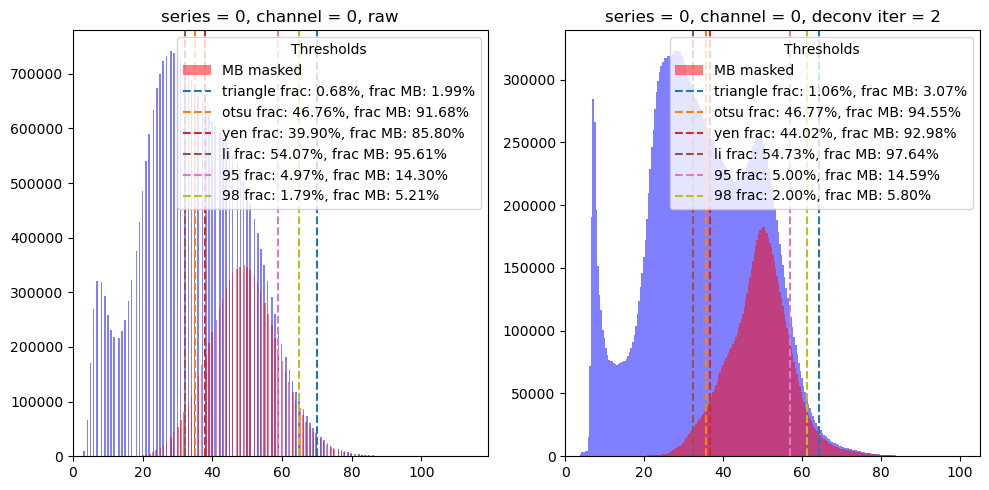

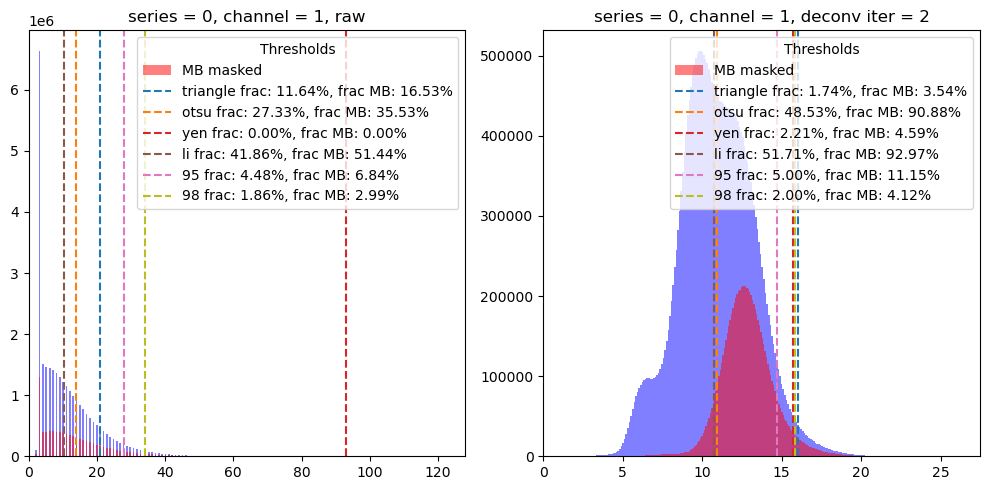

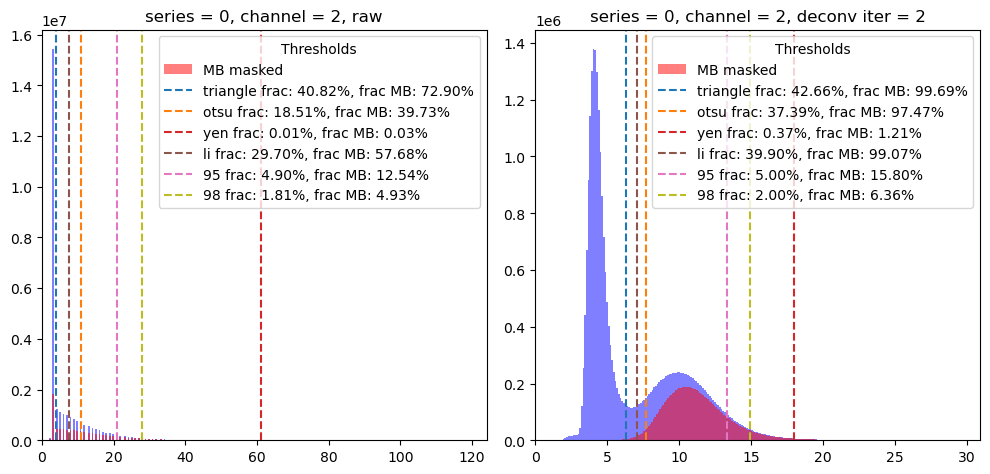

Processing series 1---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_1/channel_0/2026_06_15_s1_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

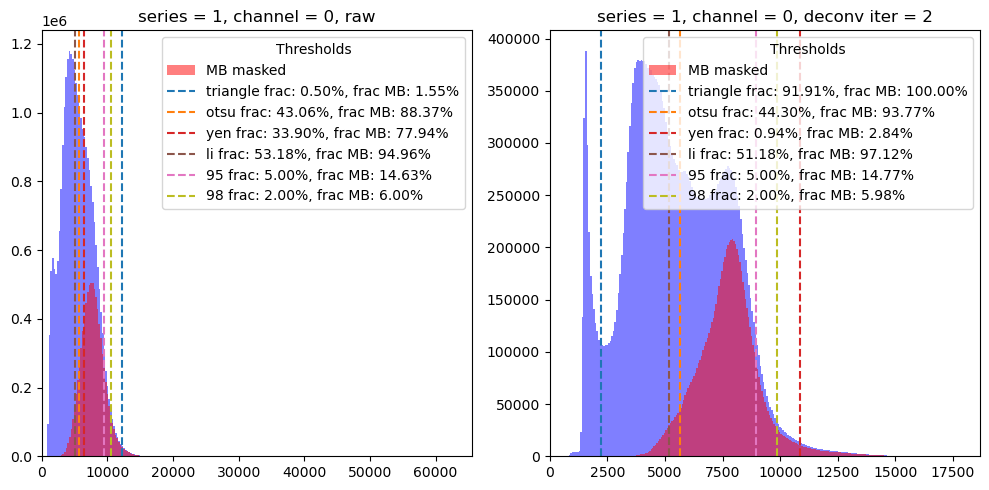

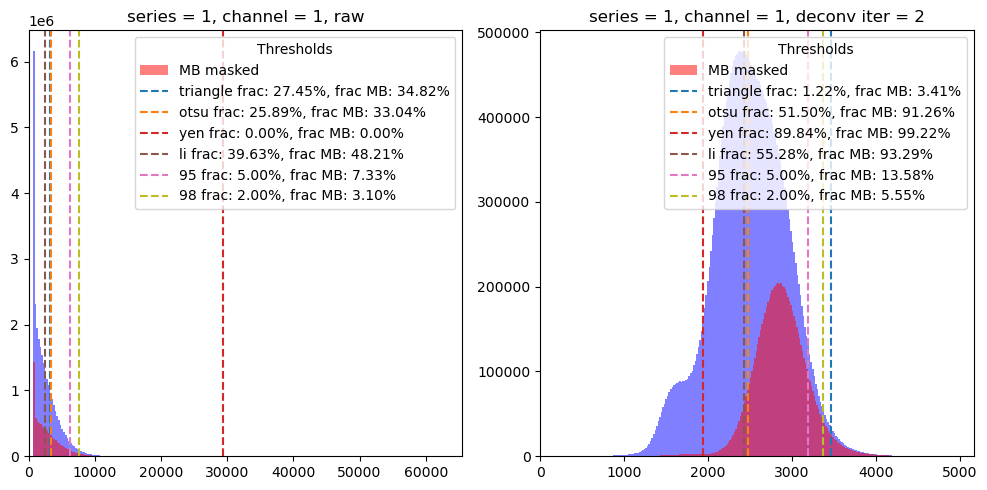

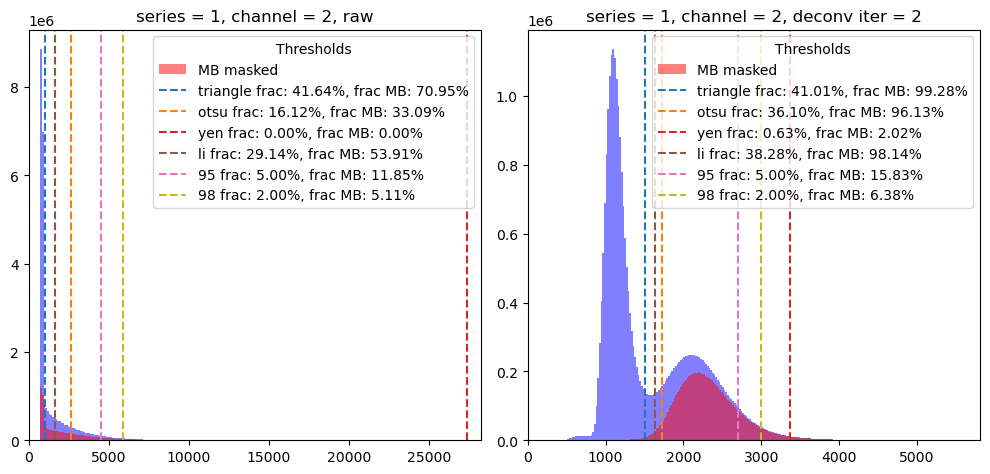

Processing series 2---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_2/channel_0/2026_06_15_s2_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

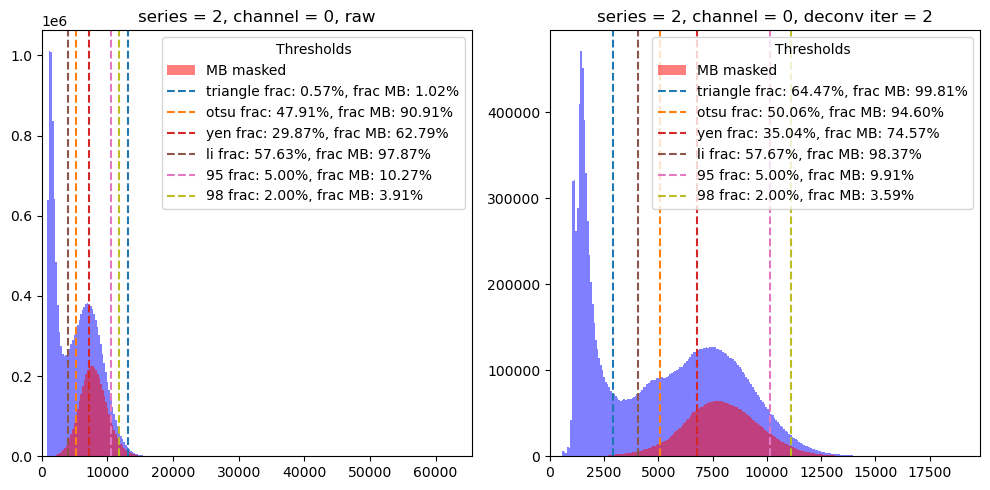

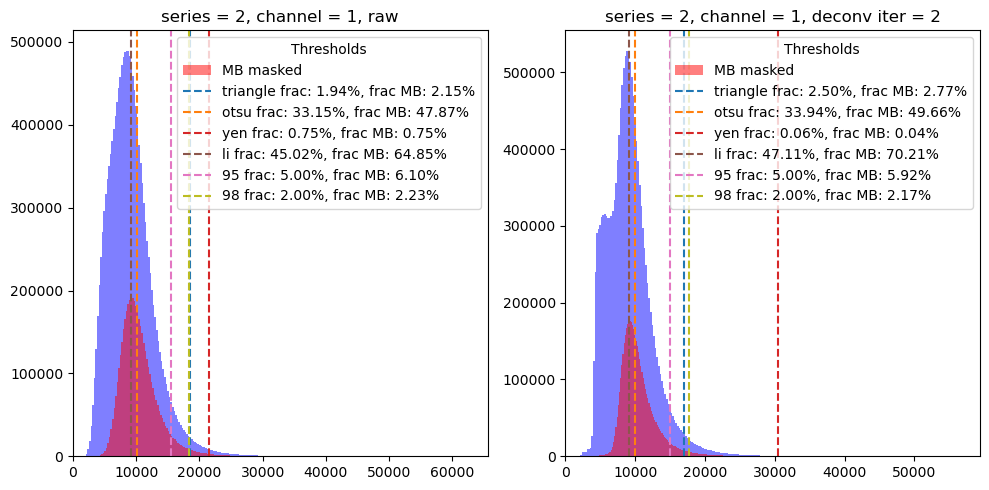

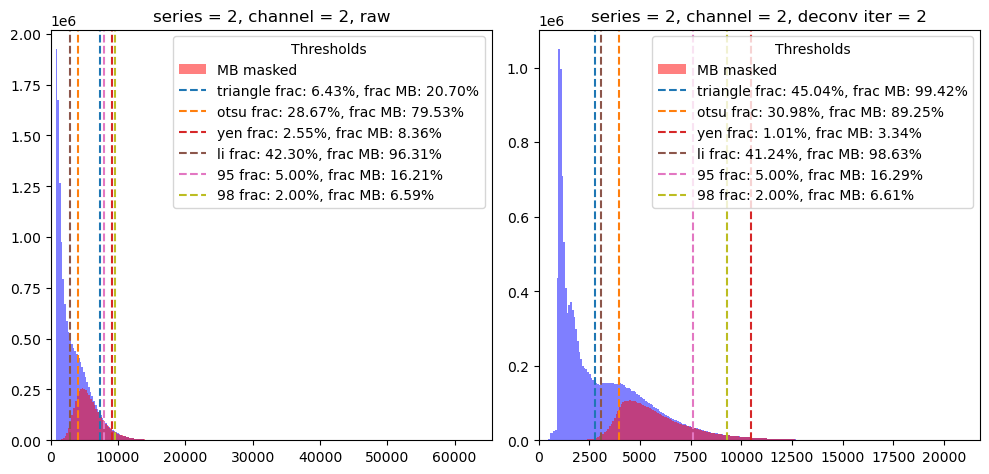

Processing series 3---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_3/channel_0/2026_06_15_s3_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

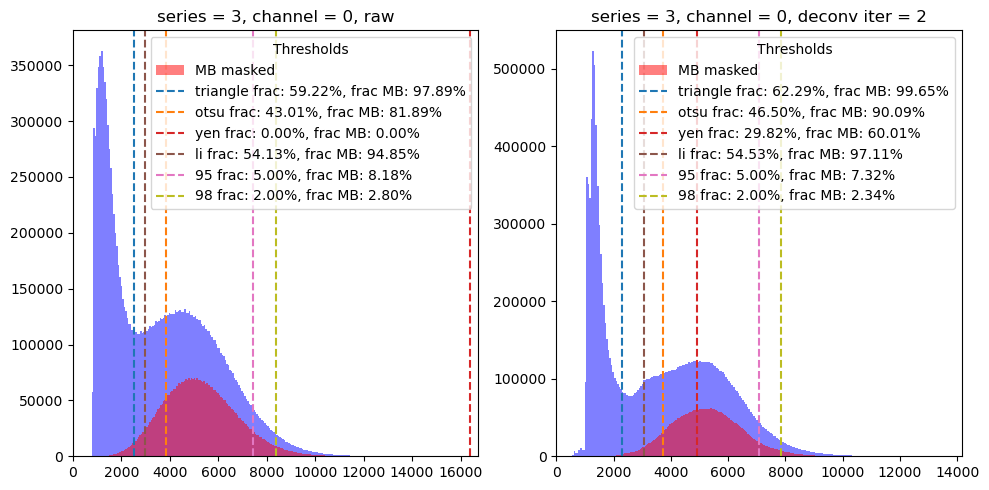

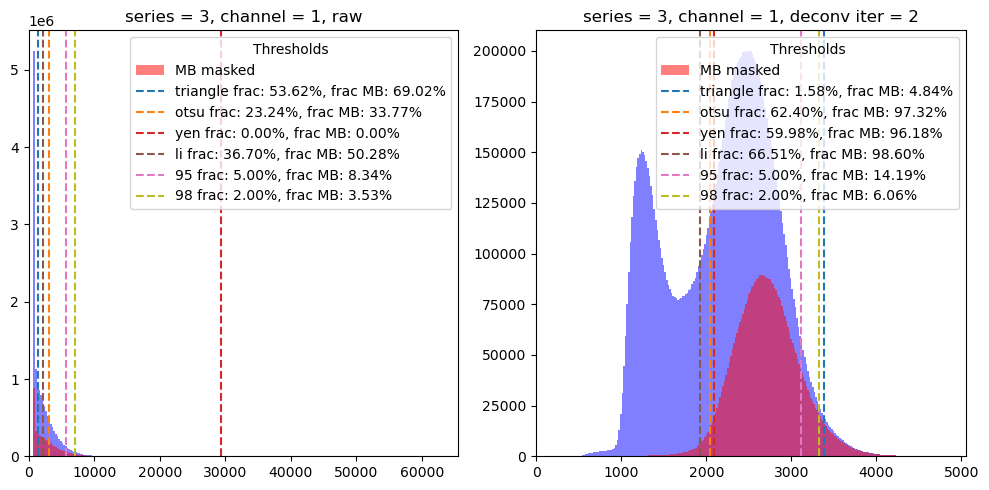

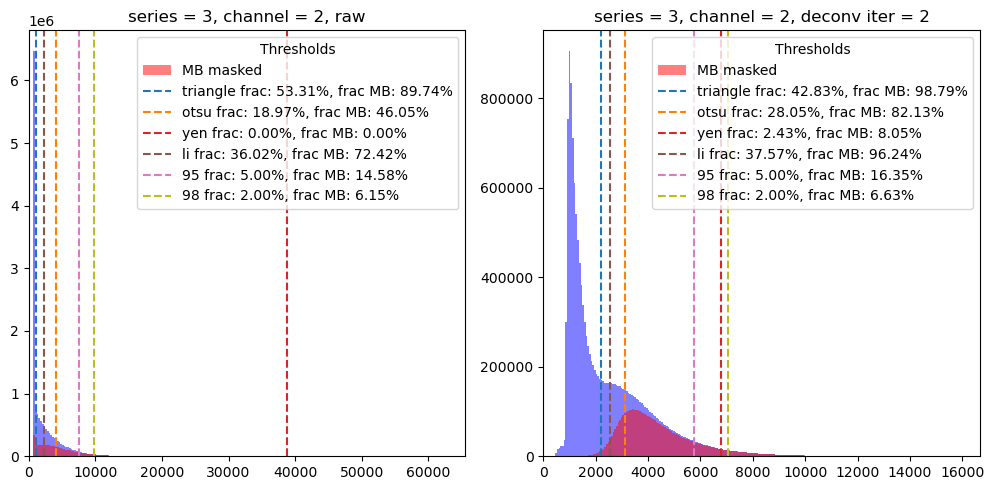

Processing series 4---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_4/channel_0/2026_06_15_s4_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

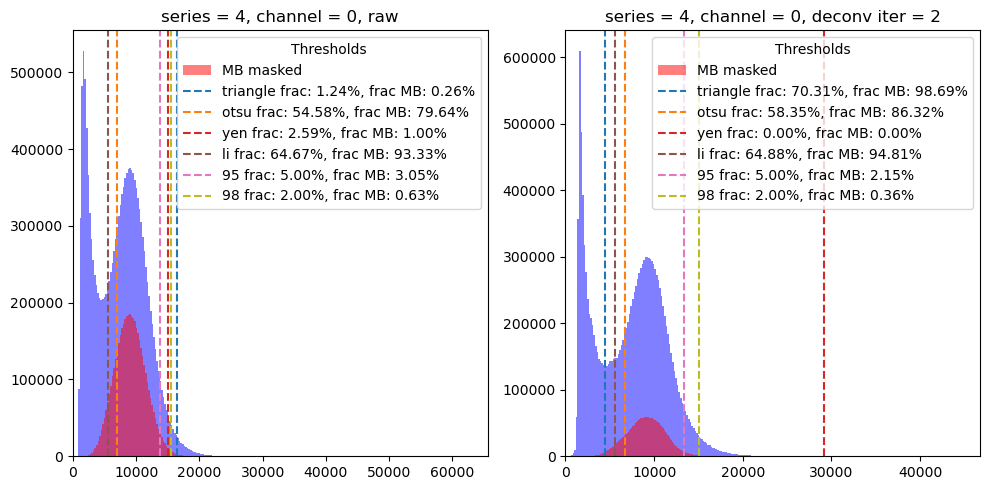

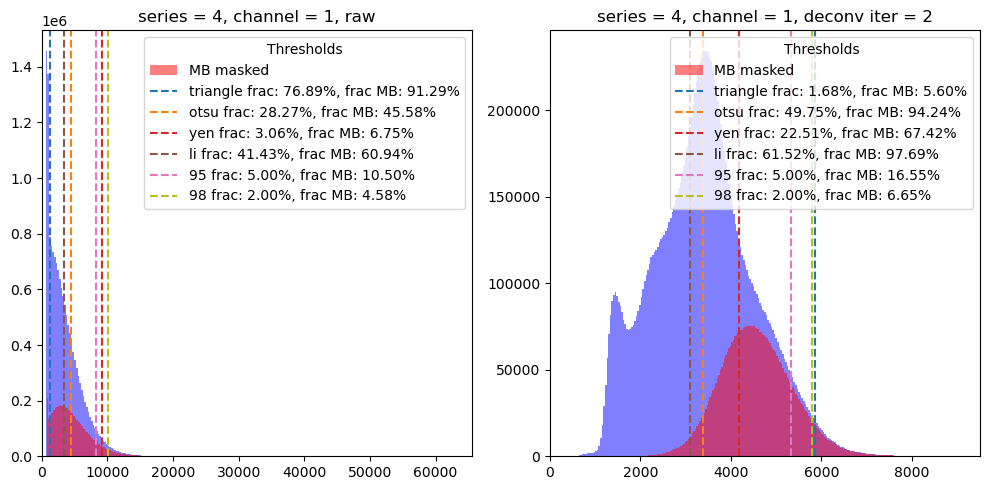

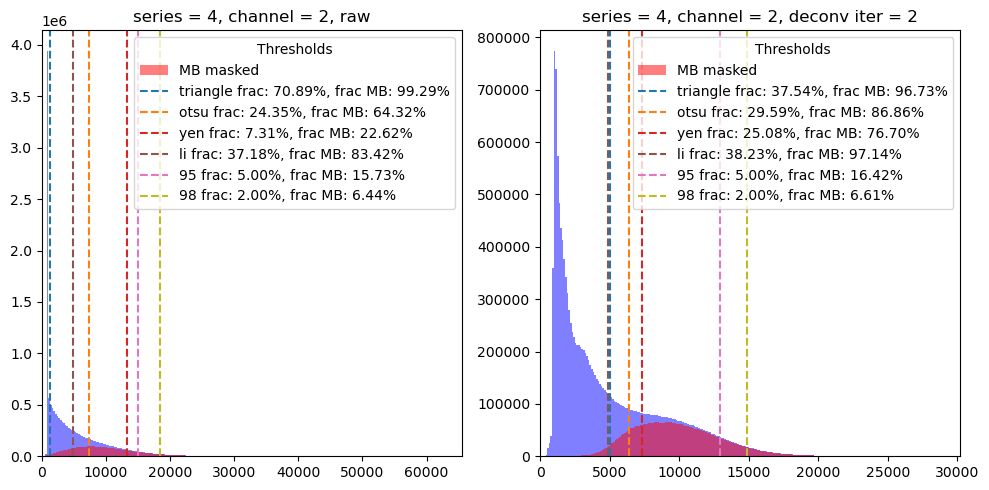

Processing series 5---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_5/channel_0/2026_06_15_s5_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

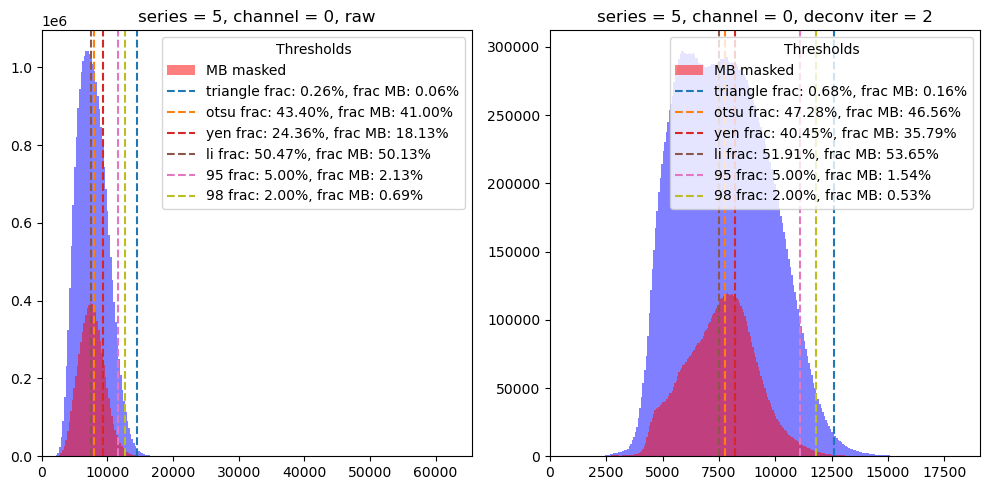

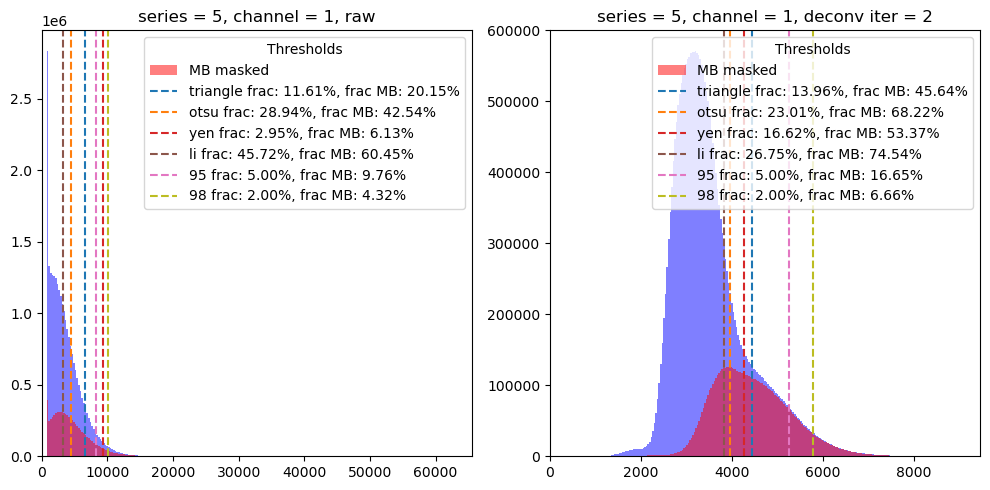

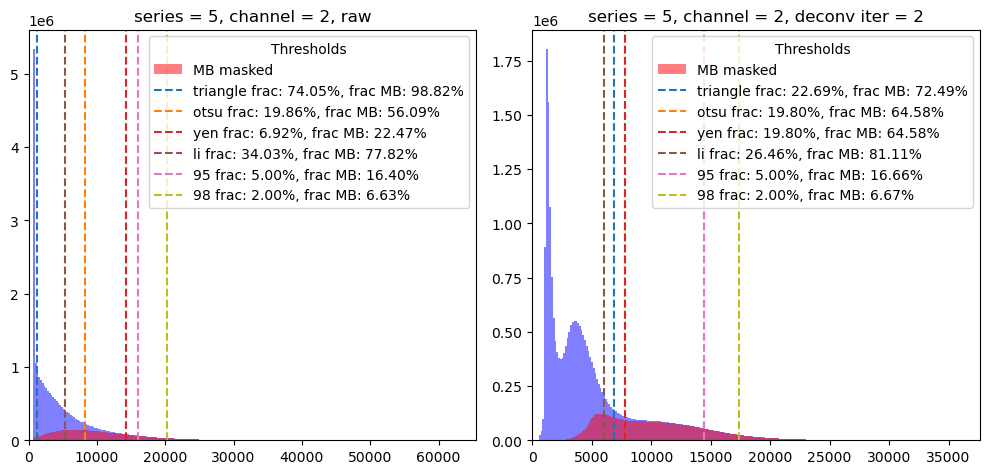

Processing series 6---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_6/channel_0/2026_06_15_s6_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

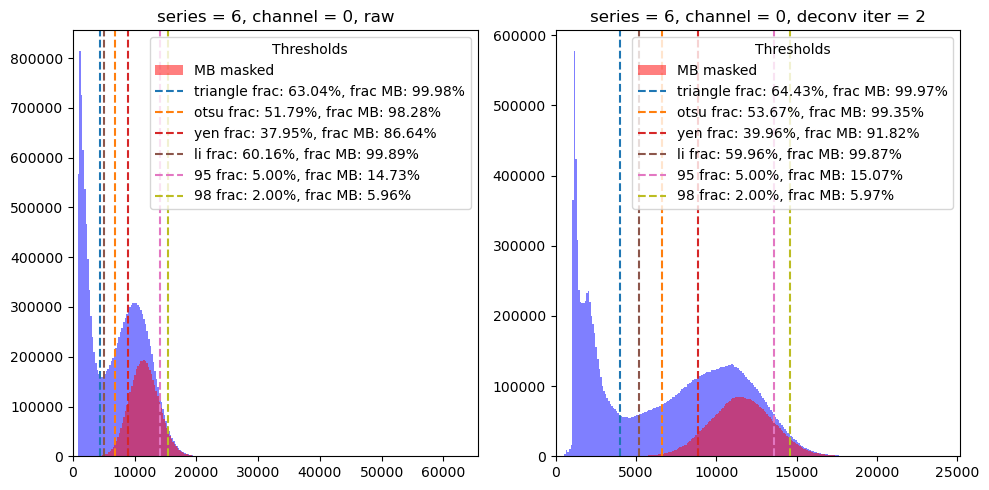

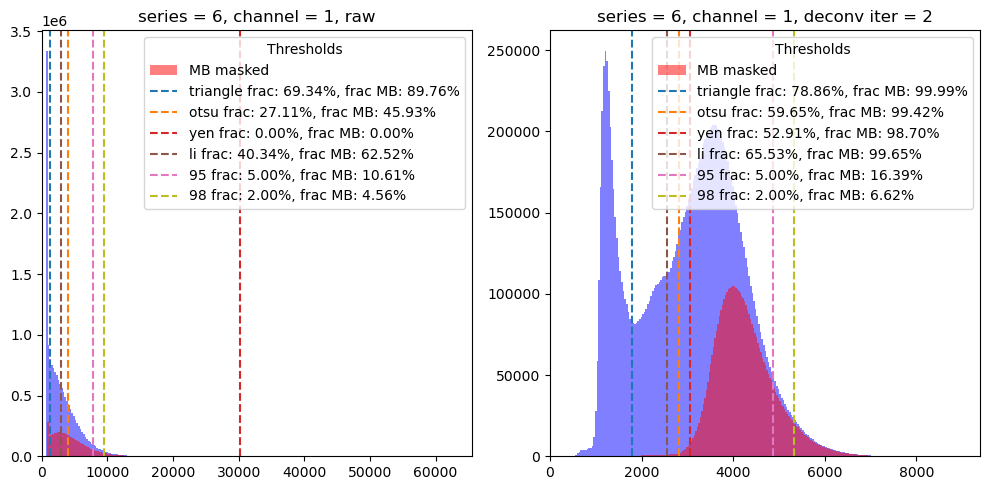

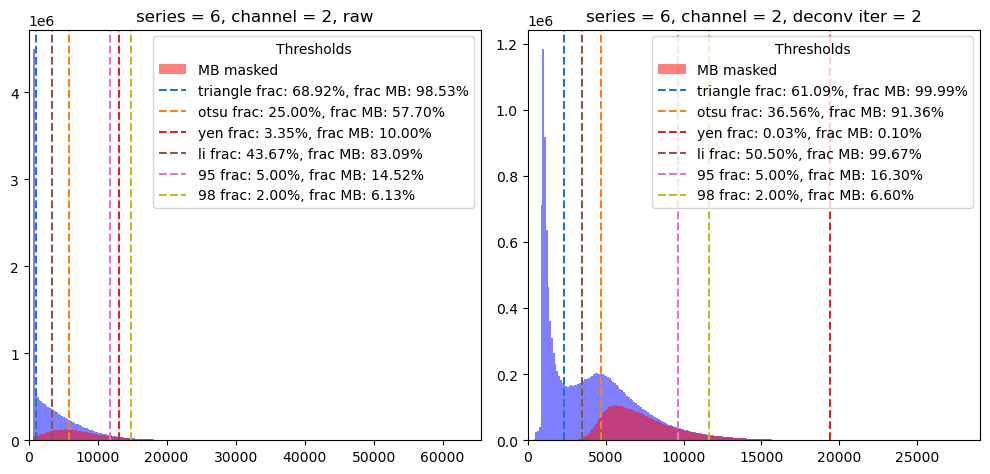

Processing series 7---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_7/channel_0/2026_06_15_s7_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

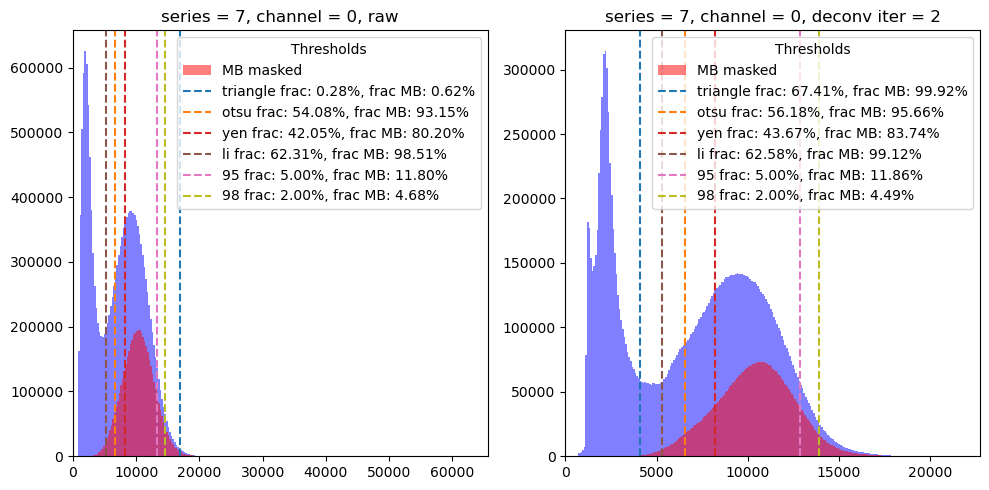

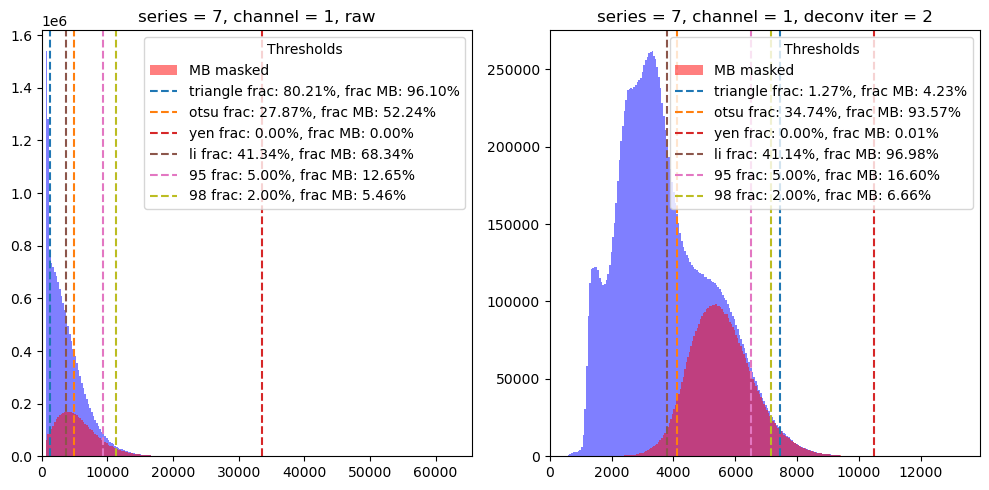

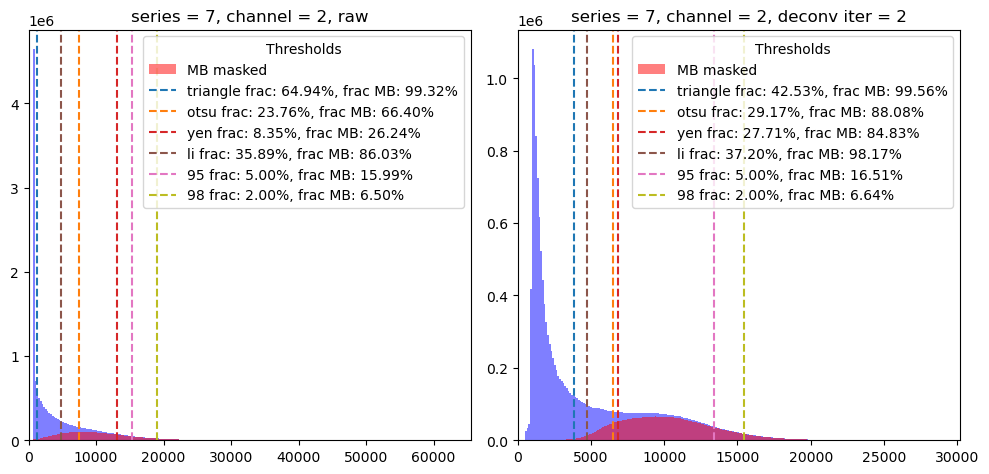

Processing series 8---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_8/channel_0/2026_06_15_s8_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

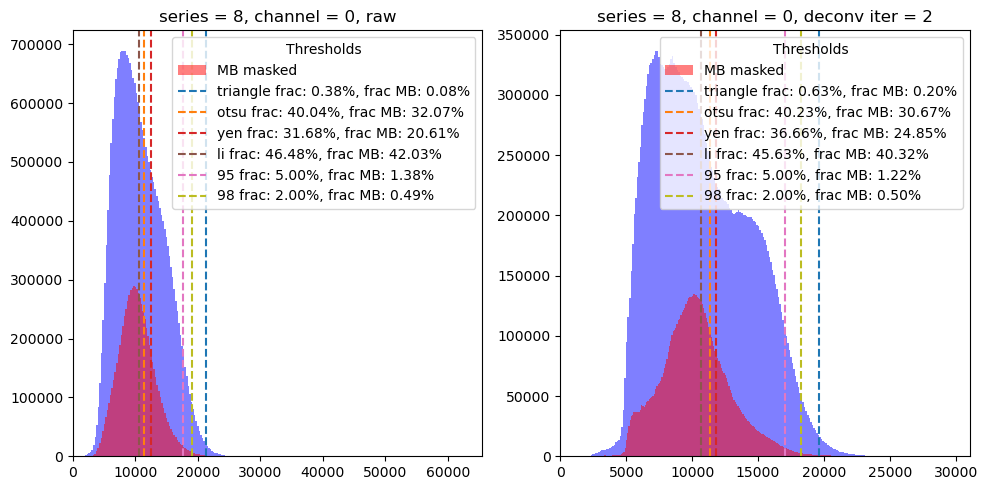

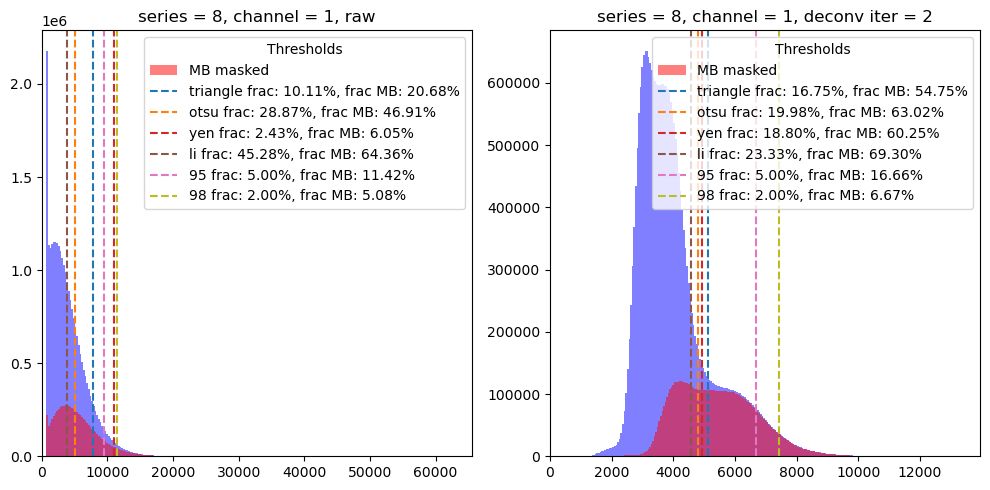

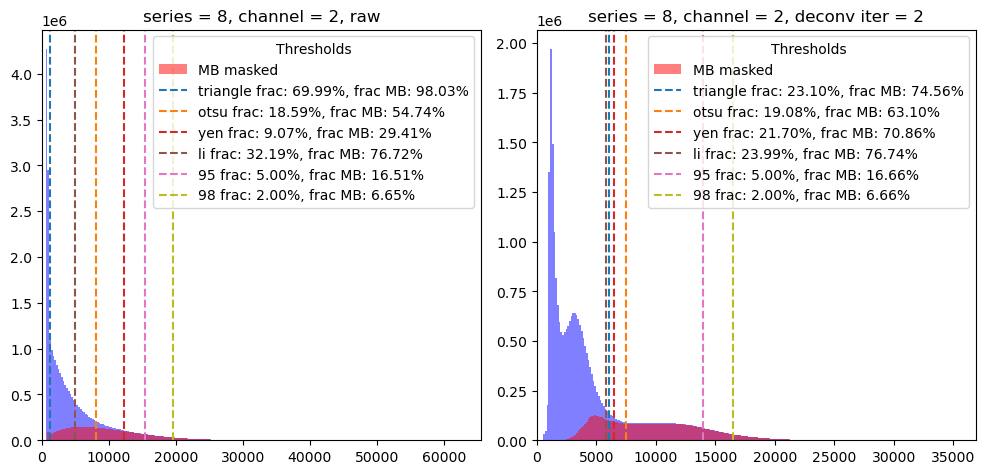

Processing series 9---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_9/channel_0/2026_06_15_s9_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/

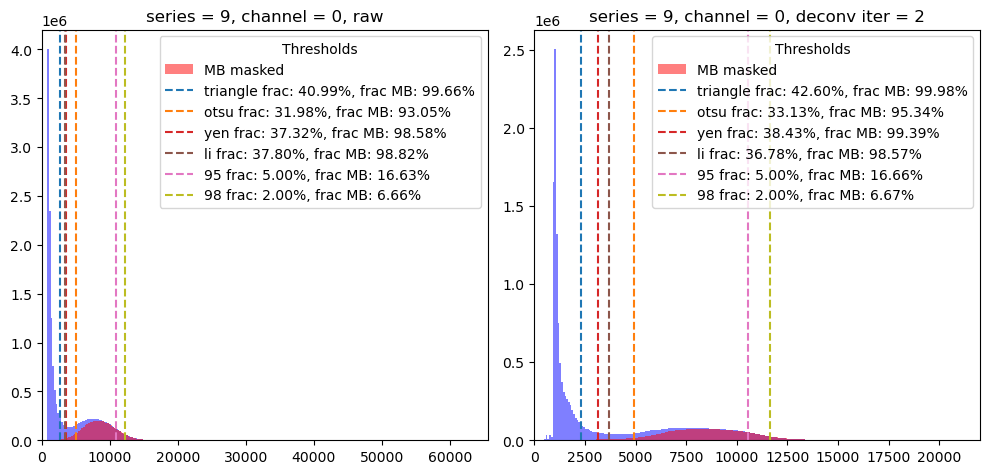

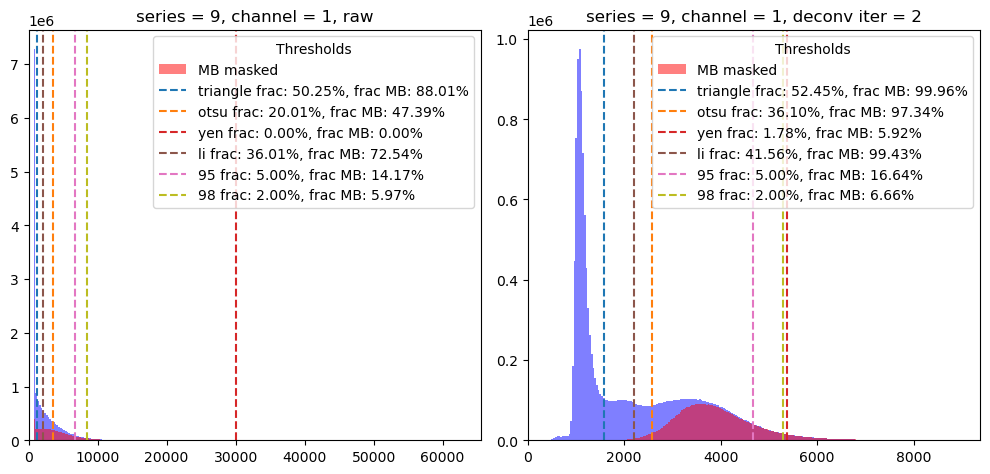

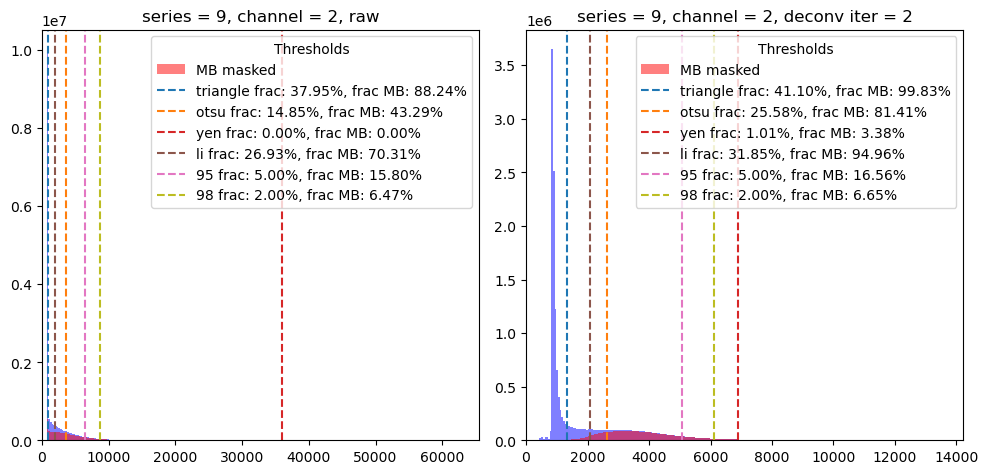

Processing series 10---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_10/channel_0/2026_06_15_s10_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/20

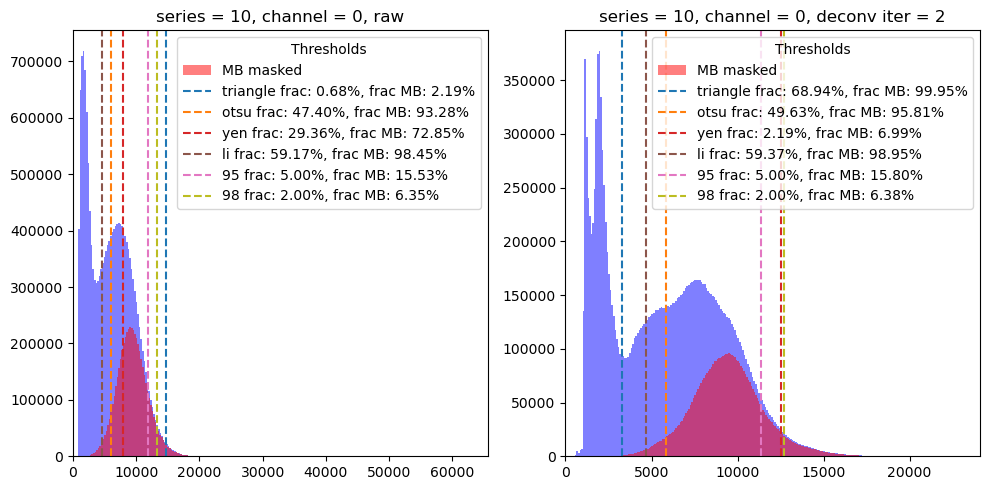

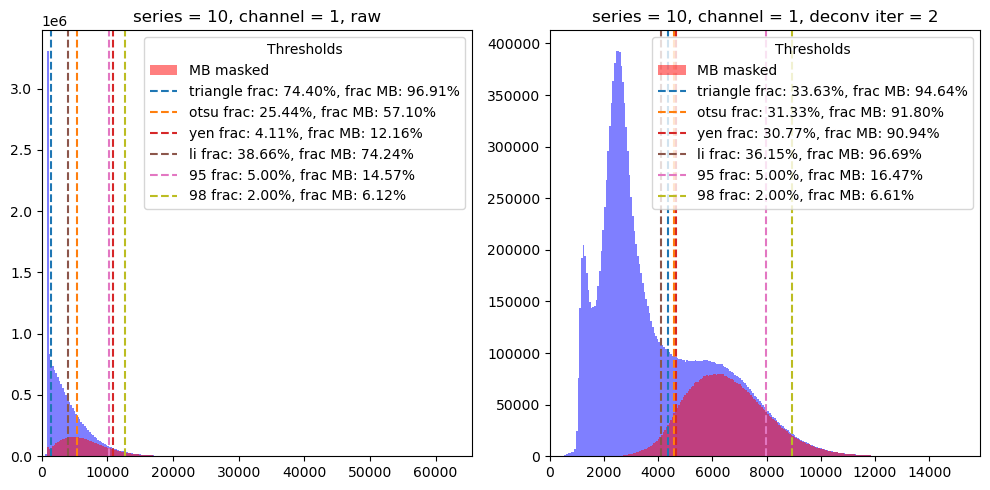

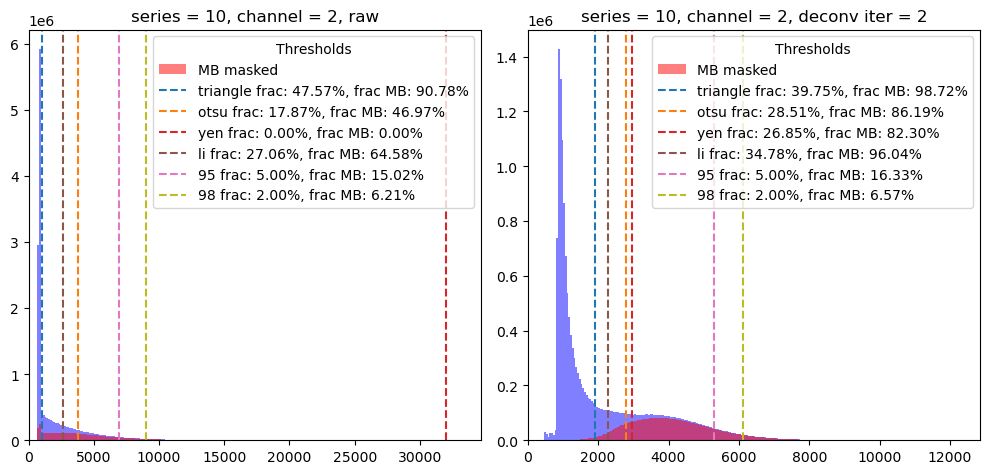

Processing series 11---------------
Channel 0************************
raw ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_triangle.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_otsu.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_yen.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_li.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_95.tif
saved /home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_masks_98.tif
deconv_iter_2 ************************
/home/gerard/data/confocal/2026_06_15_Carmina/series_11/channel_0/2026_06_15_s11_ch0_deconv2d_iter_2.tif
saved /home/gerard/data/confocal/20

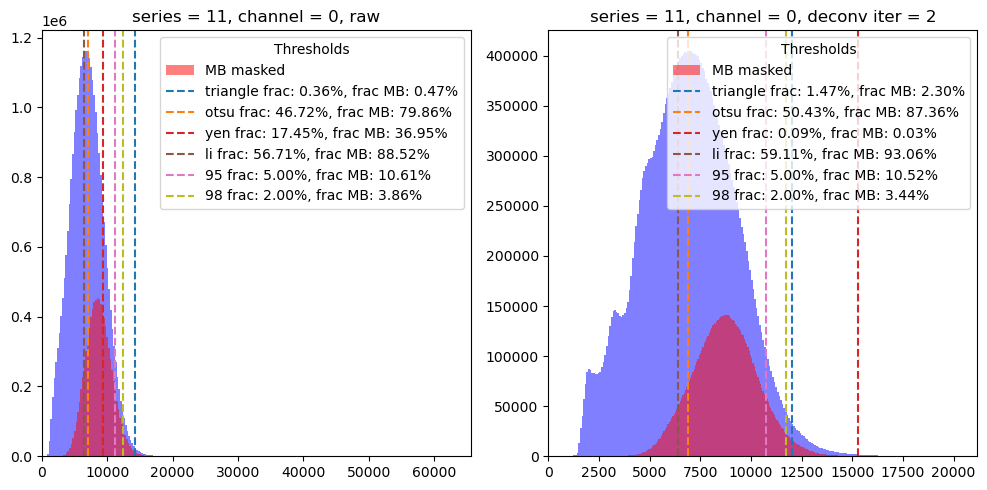

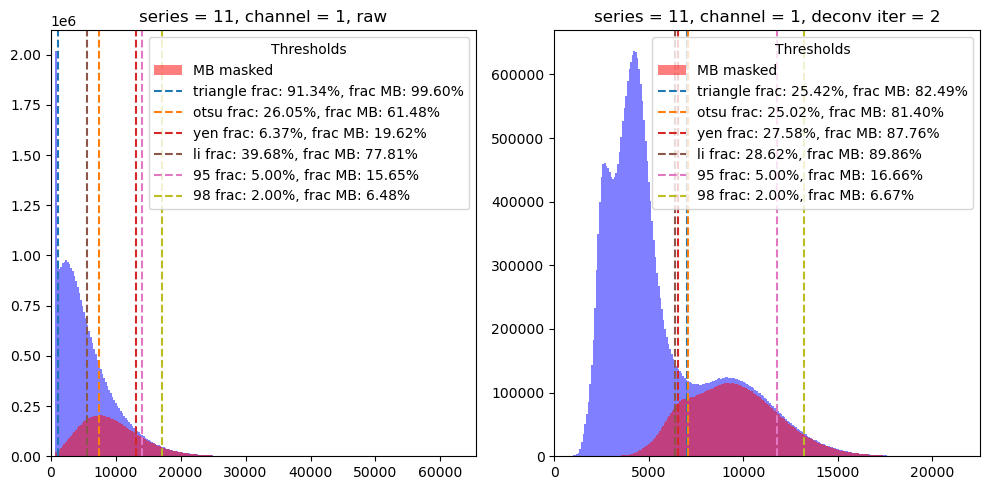

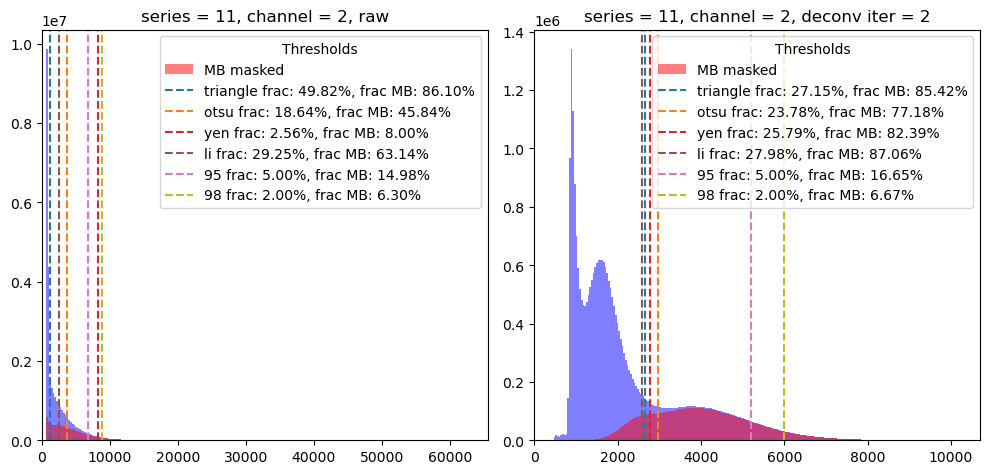

In [ ]:
#thresholding(date, user, series_list, deconv_iter_list, do_plot = True )
#scenes = list(range(len(info.keys())))

#print(list(range(len(info.keys()))))

series_list = list(range(len(info.keys())))
# series_list = [9]
# selected_series = series_list[0]
deconv_iter_list = 
results = thresholding(date, user, series_list, deconv_iter_list, channel_struct =2, do_plot = True )

In [85]:
print_dict_structure(results)

└─ s_0 (dict):
  └─ c_0 (dict):
    └─ raw (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ triangle (dict):
        └─ threshold (int64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ otsu (dict):
        └─ threshold (int64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ yen (dict):
        └─ threshold (int64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ li (dict):
        └─ threshold (float64)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
    └─ deconv_iter_2 (dict):
      └─ stack (ndarray)
      └─ stack_proj (ndarray)
      └─ triangle (dict):
        └─ threshold (float32)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ otsu (dict):
        └─ threshold (float32)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ yen (dict):
        └─ threshold (float32)
        └─ masks (ndarray)
        └─ mask_proj (ndarray)
      └─ li (dict):
        └─ thre

## Understanding the colocalization metrics

To ask whether two proteins occupy the same pixels in the image, we threshold each channel to obtain a binary mask — pixels are either positive (signal present) or negative (signal absent). All three metrics below are computed within a defined region of interest (e.g. the Mushroom Body).

---

### Directional overlap fractions (binary Manders coefficients)

These answer: *of all pixels positive for protein A, what fraction are also positive for protein B?* And vice versa.

- **Fraction of A in B** = |A∩B| / |A| — "what fraction of A pixels have B signal?"
- **Fraction of B in A** = |A∩B| / |B| — "what fraction of B pixels have A signal?"

These are directional: they can be different from each other. For example, if mitochondria are large and HSP70 is a small subset that sits on them, the fraction of HSP in Mito will be high (most HSP is on mitochondria), while the fraction of Mito in HSP will be lower (mitochondria are big, and only part of their surface has HSP).

---

### Enrichment over random

The overlap fractions alone do not tell you whether the co-localization is *more than expected by chance*. If 80% of pixels in a region are Mito-positive and 70% are HSP-positive, you would expect ~56% overlap purely by random spatial overlap, regardless of any physical association.

The enrichment corrects for this:

**Enrichment = observed overlap / expected random overlap**

where the expected overlap is calculated assuming the two signals are distributed independently within the region. An enrichment of 1.0 means no association beyond chance; an enrichment of 6× means the two proteins co-localize six times more than would be predicted if they were independently distributed.

---

### Odds ratio

The odds ratio (OR) is the most statistically rigorous of the three. It asks: *how much more likely is a pixel to be B-positive if it is A-positive, compared to if it is A-negative?*

- **OR = 1**: knowing a pixel is A-positive gives no information about B — the two signals are independent
- **OR > 1**: A-positive pixels are more likely to carry B signal — positive co-localization
- **OR = 52**: an A-positive pixel is 52 times more likely to also be B-positive than an A-negative pixel

The OR is accompanied by a p-value. With microscopy images (thousands of pixels), p-values are almost always effectively zero — what matters is the **size of the OR**, not whether p < 0.05. An OR of 2 is meaningful; an OR of 900 is dramatic.

---

### Using the three metrics together

| Metric | What it tells you |
|---|---|
| Fraction A in B | How much of A is "covered" by B |
| Fraction B in A | How much of B is "covered" by A |
| Enrichment | Is co-localization above what chance would produce? |
| Odds ratio | How strongly are A and B spatially associated? |

A complete interpretation uses all three: the fractions describe the *extent* of overlap, the enrichment shows whether it is *above chance*, and the odds ratio quantifies the *strength of association* independently of how prevalent each signal is.


In [ ]:
from scipy.stats import fisher_exact
import pandas as pd

series_list = list(range(len(info.keys())))
table_results = {}
table_results['name'] = []
table_results['mask_HSP'] = []
table_results['mask_mito'] = []    
table_results['mask_BRP'] = []

for series in series_list:
    #print(list(info.keys())[series])
    
    
    
    channels = {
        '0':'BRP',
        '1':'HSP',
        '2':'Mito',    
    }

    comparisons = [
            # [0,1],
            # [0,2],
                [1,2],
                ]

    deconv_iter = 2

    chA_thrsh_al = 'triangle'# ch1,HSP
    chB_thrsh_al = 'triangle'# ch2,Mito
    brp_thrsh_al = 'triangle' # ch0,BRP

    table_results['name'].append(list(info.keys())[series])
    table_results['mask_HSP'].append(chA_thrsh_al)
    table_results['mask_mito'].append(chB_thrsh_al)
    table_results['mask_BRP'].append(brp_thrsh_al)
    #************************************************************
    deconv_str_mask = 'deconv_iter_'+ str(deconv_iter)

    MB_mask = results['s_'+str(series)]['c_2'][deconv_str_mask]['mb'].astype(bool)
    brp_mask = results['s_'+str(series)]['c_0'][deconv_str_mask][brp_thrsh_al]['masks'].astype(bool)

    SYN_mask = MB_mask & brp_mask
    NON_SYN_mask = MB_mask & ~brp_mask
    for c in comparisons:
        
        chA_n = c[0]
        chB_n = c[1]


        mask_chA = results['s_'+str(series)]['c_'+str(chA_n)][deconv_str_mask][chA_thrsh_al]['masks'].astype(bool)
        mask_chB = results['s_'+str(series)]['c_'+str(chB_n)][deconv_str_mask][chB_thrsh_al]['masks'].astype(bool)
            
        
        
        masks2check = {'MB_total': MB_mask,
                    'MB_syn': SYN_mask,
                    'MB_non_syn' : NON_SYN_mask,
                    }
        
        for msk in masks2check.keys():
            #print(msk)
            MASK = masks2check[msk]
            
            
            mask_chA_MB = mask_chA & MASK
            mask_chB_MB = mask_chB & MASK
            overlap = mask_chA_MB & mask_chB_MB # |A∩B|
            
           ############
            A_and_B  = (mask_chA_MB &  mask_chB_MB).sum()
            A_not_B  = (mask_chA_MB & ~mask_chB_MB).sum()
            B_not_A  = (~mask_chA_MB & mask_chB_MB).sum()
            neither  = MASK.sum() - A_and_B - A_not_B - B_not_A  # fixed


            table = [[A_and_B, A_not_B],
                    [B_not_A, neither]]

            odds_ratio, pvalue = fisher_exact(table, alternative='greater') 

            
            
            ##############

            fraction_A_in_B = overlap.sum() / mask_chA_MB.sum()   # = |A∩B| / |A|:  "fraction of A that is B-positive"
            fraction_B_in_A = overlap.sum() / mask_chB_MB.sum()   # = |A∩B| / |B|:  "fraction of A that is B-positive"

            # print(f'fraction of {channels[str(chA_n)]} in {channels[str(chB_n)]}: {fraction_A_in_B:.2f}')
            # print(f'fraction of {channels[str(chB_n)]} in {channels[str(chA_n)]}: {fraction_B_in_A:.2f}')
            # print(f"odds ratio: {odds_ratio:.2f}")#, p = {pvalue:.2e}")

            
            pA = mask_chA_MB.sum() / MASK.sum()
            pB = mask_chB_MB.sum() / MASK.sum()

            # Expected overlap:
            observed = overlap.sum()
            expected = pA * pB * MASK.sum()

            #print(f'observed={observed}, expected={expected:.2f}')
            #print (f'the observed enrichment is {(observed/expected):.2f} bigger than expected.')
           
            column1 = msk + '_' +f'fraction of {channels[str(chA_n)]} in {channels[str(chB_n)]}'
            column2 = msk + '_' +f'fraction of {channels[str(chB_n)]} in {channels[str(chA_n)]}'
            column3 = msk + '_' + 'odds_ratio'
            column4 = msk + '_' + 'enrichment'
            
            if column1 not in table_results.keys():
                table_results[column1] = []
            if column2 not in table_results.keys():
                table_results[column2] = []
            if column3 not in table_results.keys():
                table_results[column3] = []
            if column4 not in table_results.keys(): 
                table_results[column4] = []
            
            table_results[column1].append(float(f'{fraction_A_in_B:.3f}'))
            table_results[column2].append(float(f'{fraction_B_in_A:.3f}'))
            table_results[column3].append(float(f'{odds_ratio:.3f}'))
            table_results[column4].append(float(f'{(observed/expected):.3f}'))
            

            
            #print(f'{fraction_A_in_B:.2f},{fraction_B_in_A:.2f},{odds_ratio:.2f},{(observed/expected):.2f}')
            
            
            #print('******************************')
            
#print(table_results.keys())
df = pd.DataFrame(table_results)
#print(df.to_csv(index=False))
df.to_csv('data.csv', index=False)
    


In [167]:
masks2check = {'MB_total': MB_mask,
                   'MB_syn': SYN_mask,
                   'MB_non_syn' : NON_SYN_mask,
                   }

for k in masks2check.keys():
    print(k, type(masks2check[k]))

MB_total <class 'numpy.ndarray'>
MB_syn <class 'numpy.ndarray'>
MB_non_syn <class 'numpy.ndarray'>


In [161]:
comparisons = [[0,1],[0,2],[1,2]]
for c in comparisons:
    print(c[0])

0
0
1


In [123]:
print(results['s_'+str(series)]['c_'+str(chA_n)][deconv_str_mask].keys())


dict_keys(['stack', 'stack_proj', 'triangle', 'otsu', 'yen', 'li'])
